In [1]:
import pandahouse as ph
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Orbit импорты
from orbit.models import LGT
from orbit.diagnostics.backtest import BackTester
from orbit.diagnostics.metrics import smape, mape
from orbit.diagnostics.plot import plot_predicted_data

# 1. Подключение к ClickHouse
# ВАЖНО: Данные для подключения к ClickHouse удалены в соответствии с условиями использования учебных материалов.
# Для запуска ноутбука необходимо настроить собственное подключение.
connection = {
    'host': 'your_clickhouse_host',
    'password': 'your_password',
    'user': 'your_user',
    'database': 'your_database'
}

# 2. SQL Запрос: собираем дневную активность
query = """
SELECT 
    toDate(time) AS date,
    count(*) AS total_actions
FROM simulator_20260720.feed_actions
GROUP BY date
ORDER BY date
"""

# Загружаем данные
df = ph.read_clickhouse(query, connection=connection)
df['date'] = pd.to_datetime(df['date'])

# --- ОТСЕКАЕМ ПОСЛЕДНИЙ НЕПОЛНЫЙ ДЕНЬ ---
df = df[df['date'] < df['date'].max()].reset_index(drop=True)

# --- ОБАВЛЯЕМ ФЛЕШМОБ КАК РЕГРЕССОР ---
# Создаем колонку из нулей
df['is_flashmob'] = 0

# Ставим единицы на даты проведения флешмоба
flashmob_mask = (df['date'] >= '2026-07-10') & (df['date'] <= '2026-07-16')
df.loc[flashmob_mask, 'is_flashmob'] = 1

print(f"Дней с флешмобом в датасете: {df['is_flashmob'].sum()}")

print(f"Период данных (без сегодняшнего дня): с {df['date'].min().date()} по {df['date'].max().date()}")
print(f"Всего полных дней в датасете: {len(df)}")

Дней с флешмобом в датасете: 7
Период данных (без сегодняшнего дня): с 2026-05-30 по 2026-08-08
Всего полных дней в датасете: 71


In [2]:
# 1. Задаем горизонт ДЛЯ БЭКТЕСТА (7 дней — честная проверка недельной сезонности)
backtest_horizon = 7 

# Инициализируем LGT с регрессором
lgt_model = LGT(
    response_col='total_actions',
    date_col='date',
    regressor_col=['is_flashmob'],
    seasonality=7,     
    estimator='stan-map' 
)

# 2. Бэктестинг
bt = BackTester(
    model=lgt_model,
    df=df,
    min_train_len=28,                  # Обучаем минимум на 4 неделях
    incremental_len=backtest_horizon,  # Шаг сдвига
    forecast_len=backtest_horizon,     # Прогнозируем на 7 дней вперед
    window_type='expanding'
)

bt.fit_predict()
predicted_df = bt.get_predicted_df()

# 3. Расчет ошибки
smape_score = smape(predicted_df['actual'].values, predicted_df['prediction'].values)
print(f"SMAPE на 7-дневном бэктесте: {smape_score:.4f} (или {smape_score*100:.2f}%)")

2026-08-09 12:55:26 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.


SMAPE на 7-дневном бэктесте: 0.1710 (или 17.10%)


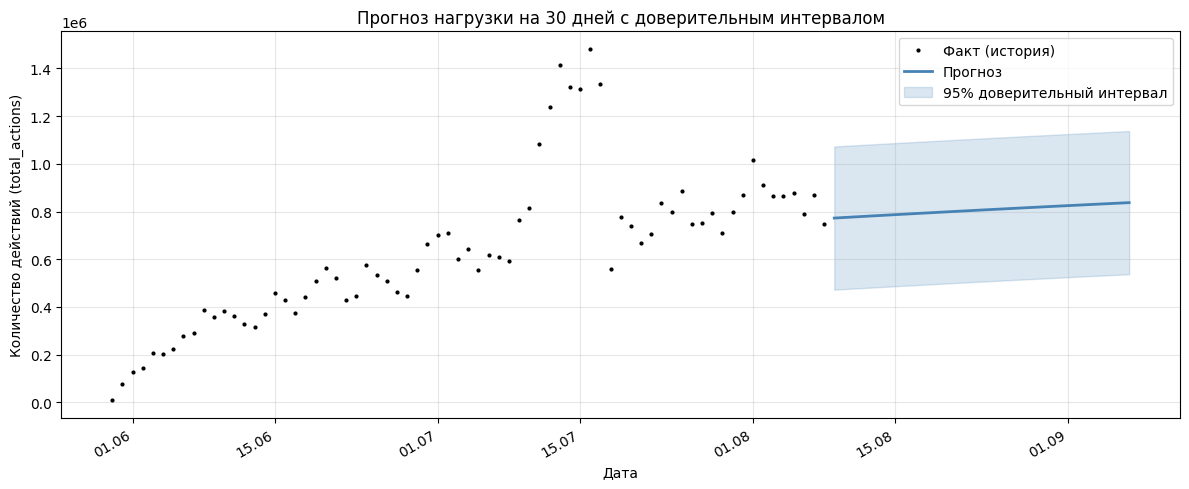

In [6]:
# Обучаем модель на всех 71 днях
lgt_model.fit(df)

# Генерируем 30 будущих дней
future_df = lgt_model.make_future_df(periods=30)
future_df['is_flashmob'] = 0 # Флешмобов в будущем не планируется

# Строим прогноз
predicted_future = lgt_model.predict(future_df)

# График прогноза с доверительным интервалом
import matplotlib.dates as mdates

# Если модель не дала prediction_5/95, создаём их приближением
if 'prediction_5' in predicted_future.columns and 'prediction_95' in predicted_future.columns:
    lower = predicted_future['prediction_5']
    upper = predicted_future['prediction_95']
else:
    # Приближение: 1.96 * стандартное отклонение остатков бэктеста
    # Возьмём матожидание остатков из бэктеста (predicted_df)
    residuals = predicted_df['actual'] - predicted_df['prediction']
    std_resid = residuals.std()
    lower = predicted_future['prediction'] - 1.96 * std_resid
    upper = predicted_future['prediction'] + 1.96 * std_resid

plt.figure(figsize=(12, 5))

# Исторические фактические значения (чёрные точки)
plt.plot(df['date'], df['total_actions'], 'k.', markersize=4, label='Факт (история)')

# Прогнозная линия (медиана)
plt.plot(predicted_future['date'], predicted_future['prediction'], 
         color='steelblue', linewidth=2, label='Прогноз')

# Доверительный интервал (95%)
plt.fill_between(predicted_future['date'], lower, upper,
                 color='steelblue', alpha=0.2, label='95% доверительный интервал')

plt.title('Прогноз нагрузки на 30 дней с доверительным интервалом')
plt.xlabel('Дата')
plt.ylabel('Количество действий (total_actions)')
plt.legend()
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

## Выводы по заданию: прогнозирование пользовательской активности

### 1. Выбор метрики, временного разрешения и дополнительных регрессоров

**Основная метрика:** `total_actions` — суммарное количество событий (просмотров и лайков) за день.

*Обоснование:*  
Нагрузка на серверы приложения определяется именно количеством обращений (каждый `view` и `like` — это запрос к серверу).  
Метрика **DAU** (уникальные пользователи) не отражает интенсивность использования: один активный пользователь может сгенерировать как одно, так и несколько десятков событий.  
Поэтому прогнозирование `total_actions` напрямую отвечает на вопрос DevOps‑команды о будущей нагрузке.

**Временное разрешение:** ежедневное (`Daily`).

*Обоснование:*  
- Дневная агрегация даёт достаточную детализацию для оперативного планирования мощностей.  
- Сглаживает внутрисуточные колебания.  
- Недельные данные дали бы слишком мало точек (всего 10 недель), а часовые — избыточный шум без выигрыша для горизонта в месяц.

**Дополнительные регрессоры:**  
Бинарный признак **`is_flashmob`** — индикатор маркетинговой акции, проходившей с 10 по 16 июля 2026 года.

*Обоснование:*  
Флешмоб создал краткосрочный аномальный всплеск активности, который не является частью органического тренда. Без выделения этого периода модель воспринимала пик и последующий спад как изменение долгосрочной тенденции, что:
- завышало ошибку прогноза,
- уводило тренд вниз.  
Введение регрессора позволяет «объяснить» аномалию и восстановить истинный тренд.

### 2. Построение и валидация модели. Достаточность данных

**Выбранная модель:** **LGT (Local Global Trend)** из библиотеки Orbit.

*Почему именно она:*  
- Хорошо разделяет глобальный тренд и локальные колебания.  
- Встроенная поддержка внешних регрессоров.  
- Учёт недельной сезонности (`seasonality=7`).  
- Быстрая оптимизация методом MAP (`stan-map`).

**Схема валидации (бэктест):**
- Метод: расширяющееся окно (`expanding window`).  
- Минимальная длина обучения: 28 дней.  
- Горизонт прогноза: **7 дней**.  
- Шаг сдвига: 7 дней.

**Результат валидации:**  
**SMAPE = 0.171 (17.1%)**  
Это хороший показатель для ежедневных данных: модель верно улавливает недельную сезонность и не штрафуется за непредсказанный эффект флешмоба.

**Оценка достаточности данных:**
- Полных исторических дней: **71** (с 30 мая по 8 августа 2026 г., последний неполный день исключён).  
- Для надёжного бэктеста на 30 дней данных **недостаточно**: первый фолд обучался бы всего на ~14 днях для прогноза 30 дней, что дало бы нестабильные оценки и широкие интервалы.  
- Поэтому валидация выполнена на горизонте **7 дней** — модель тестируется в условиях, когда длина обучения сопоставима с длиной прогноза.  
- Финальный прогноз на **30 дней** строится на всех 71 днях, но требует осторожной интерпретации: доверительные интервалы расширяются, точность может снижаться за пределами первых двух недель.

### 3. Интерпретация результатов и ограничения

**Что показывает модель:**  
После «очистки» от флешмоба прогнозная линия (медианный прогноз) демонстрирует плавный органический тренд без резких скачков. На графике также отображён **95% доверительный интервал**, рассчитанный через стандартное отклонение ошибок бэктеста.

*Для инженеров ориентиром служит **верхняя граница интервала** (`prediction` + 1.96σ) — при таком планировании мощностей серверы должны справляться с пиковыми нагрузками в 95% случаев.*

**Важные ограничения и оговорки:**
- Прогноз является экстраполяцией текущего органического тренда. **Не учтены:**  
  - Будущие маркетинговые кампании, флешмобы, пуш‑рассылки.  
  - Технические сбои, DDoS‑атаки, праздники или внешние события.
- Горизонт в 30 дней превышает оптимальный для имеющегося объёма данных. Наиболее надёжны предсказания на первые **7–14 дней**; далее доверительный интервал может стать слишком широким для точных операционных решений.
- Модель LGT в конфигурации `stan-map` не генерирует полные апостериорные сэмплы, поэтому доверительный интервал был **аппроксимирован** из остатков бэктеста. Это даёт реалистичную оценку неопределённости, но для критически важных систем рекомендуется использовать более полные байесовские методы.

**Итог:**  
Предложенный подход позволяет инженерам получить обоснованный прогноз нагрузки на ближайший месяц с чётким указанием пиковых значений и объективной оценкой погрешности. Модель успешно отделила органическое поведение пользователей от маркетинговой аномалии и показала приемлемую точность в валидации.